# Monte Carlo Stock-Price Simulation Using GBM

This project uses Monte Carlo simulation to generate possible future stock-price paths under geometric Brownian motion (GBM). The analysis examines how uncertainty develops over time, validates the simulated terminal distribution against analytical GBM results, and investigates how volatility changes the distribution of possible outcomes. The simulations are conditional scenarios based on assumed model parameters.
They are not forecasts of a specific security.

## 1. Research Question and Model
The GBM price update is

$$
S_{t+\Delta t}
=
S_t\exp\left[
\left(\mu-\frac{\sigma^2}{2}\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right],
\qquad Z\sim\mathcal{N}(0,1).
$$

Here, $S_t$ is the current price, $\mu$ is the assumed annual return,
$\sigma$ is annualized volatility, and $Z$ represents a standard-normal
random shock.


## 2. Imports and Visualization Style

In [216]:
import numpy as np 
import matplotlib.pyplot as plt

# choose and record a seed
rng_single = np.random.default_rng(10)
rng_paths = np.random.default_rng(10)

In [232]:
# Rosé Pine Moon color palette
rose_pine = {
    "base": "#232136",
    "surface": "#2a273f",
    "overlay": "#393552",
    "muted": "#6e6a86",
    "subtle": "#908caa",
    "text": "#e0def4",
    "love": "#eb6f92",
    "gold": "#f6c177",
    "rose": "#ea9a97",
    "pine": "#3e8fb0",
    "foam": "#9ccfd8",
    "iris": "#c4a7e7",
}

# Apply the theme to all subsequent plots
plt.rcParams.update({
    "figure.facecolor": rose_pine["base"],
    "axes.facecolor": rose_pine["base"],
    "savefig.facecolor": rose_pine["base"],

    "text.color": rose_pine["text"],
    "axes.labelcolor": rose_pine["subtle"],
    "axes.titlecolor": rose_pine["text"],

    "xtick.color": rose_pine["subtle"],
    "ytick.color": rose_pine["subtle"],

    "axes.edgecolor": rose_pine["overlay"],
    "grid.color": rose_pine["overlay"],
    "grid.alpha": 0.7,
    "axes.grid": True,
    "axes.axisbelow": True,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "legend.facecolor": rose_pine["surface"],
    "legend.edgecolor": rose_pine["subtle"],
    "legend.labelcolor": rose_pine["text"],

    "axes.prop_cycle": plt.cycler(
        color=[
            rose_pine["love"],
            rose_pine["gold"],
            rose_pine["rose"],
            rose_pine["pine"],
            rose_pine["foam"],
            rose_pine["iris"],
        ]
    ),

    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "lines.linewidth": 2,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## 3. Simulation Parameters

In [221]:
S0 = 100 #initial stock pricew
mu = 0.08 #assumed expected annual return
sigma = 0.20 #volatility (annual)
T = 1  #forecast horizon - 1 year 
n_steps = 252  # 252 trading days

dt = T / n_steps  #time step 
time = np.linspace(0, T, n_steps + 1)  #defining the linear time array

## 4. Simulating One GBM Price Path

In [70]:
price = np.empty(n_steps + 1)
price[0] = S0

for step in range(1, n_steps + 1):
    z = rng_single.normal(0, 1)

    deterministic = (mu - 0.5 * sigma**2) * dt
    stochastic = sigma * np.sqrt(dt) * z

    price[step] = price[step - 1] * np.exp(deterministic + stochastic)

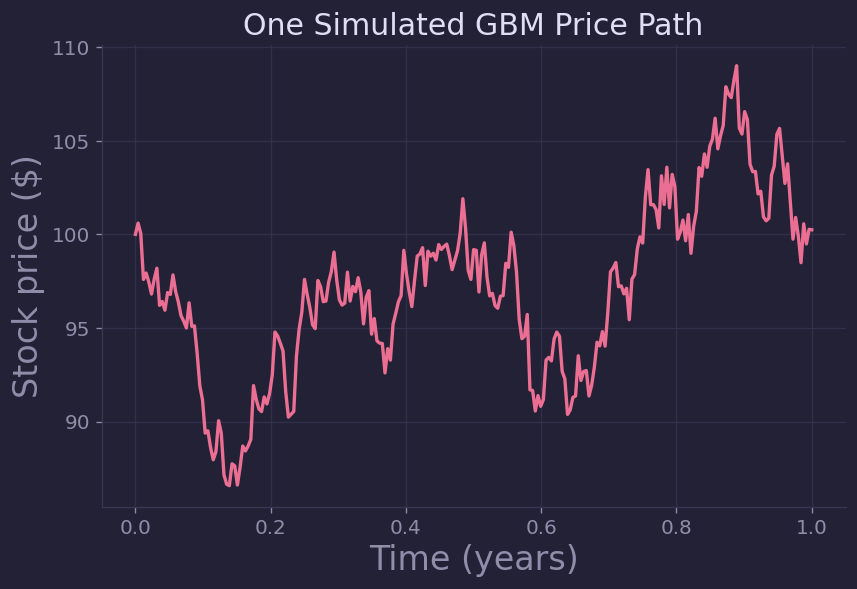

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time, price, color=rose_pine["love"], linewidth=2)

ax.set_title("One Simulated GBM Price Path")
ax.set_xlabel("Time (years)", fontsize = 20)
ax.set_ylabel("Stock price ($)", fontsize = 20)

plt.show()

## 5. Extending the Simulation to 10,000 Paths

In [239]:
n_paths = 10_000
z = rng_paths.standard_normal((n_paths, n_steps))
log_increment = ( (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
log_growth = np.cumsum(log_increment, axis=1)

# Attach an initial-price column before the simulated future prices.
future_prices = S0 * np.exp(log_growth)
initial_prices = np.full((n_paths, 1), S0)

price_paths = np.column_stack([initial_prices, future_prices])

## 6. Model-Implied Percentile Bands

In [242]:
#calculate the percentiles
p05, p25, p50, p75, p95 = np.percentile(price_paths,[5, 25, 50, 75, 95],axis=0)

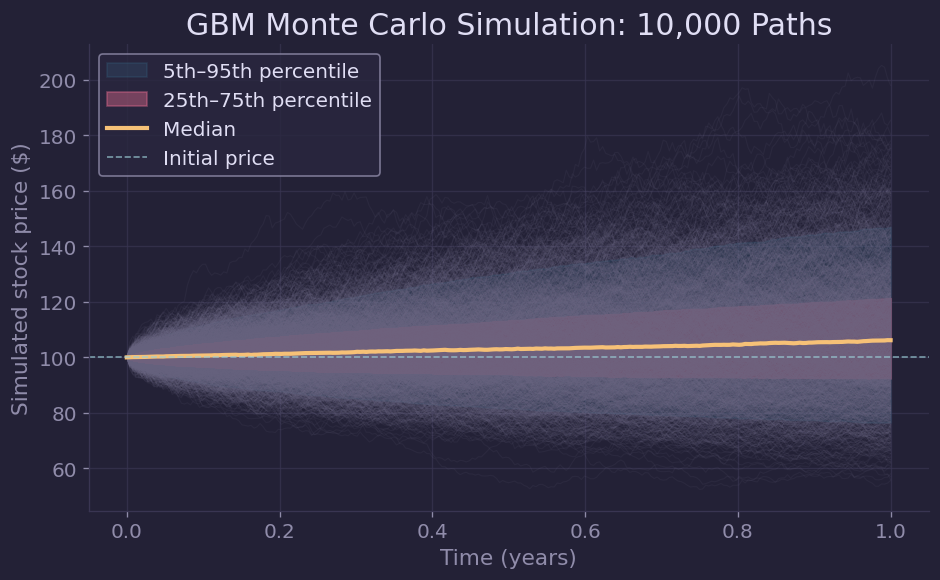

In [244]:
fig, ax = plt.subplots(figsize=(8, 5))

# Show a small sample of individual paths
for path in price_paths[:2000]:
    ax.plot(time,path,color=rose_pine["muted"],alpha=0.1,linewidth=0.7)

# Wider percentile band
ax.fill_between(time,p05,p95,color=rose_pine["pine"],alpha=0.15,label="5th–95th percentile")

# Narrower percentile band
ax.fill_between(time,p25,p75,color=rose_pine["love"], alpha=0.4,label="25th–75th percentile")

# Median simulated price
ax.plot(time,p50,color=rose_pine["gold"],linewidth=2.5,label="Median")

ax.axhline(S0,color=rose_pine["foam"],linestyle="--",linewidth=1,alpha=0.7,label="Initial price")

ax.set_title(f"GBM Monte Carlo Simulation: {n_paths:,} Paths")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Simulated stock price ($)")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Analytical Validation
### 7.1 Expected Terminal Price

In [248]:
simulated_mean = np.mean(price_paths[:, -1])
analytical_mean = S0 * np.exp(mu * T)
relative_error = abs(simulated_mean - analytical_mean) / analytical_mean

In [250]:
print(f"Simulated terminal mean: ${simulated_mean:.2f}")
print(f"Analytical terminal mean: ${analytical_mean:.2f}")
print(f"Relative error: {relative_error:.3%}")

Simulated terminal mean: $108.13
Analytical terminal mean: $108.33
Relative error: 0.186%


### 7.2 Theoretical Terminal Median

In [199]:
the_med = S0 * np.exp((mu - 0.5*(sigma**2)) * T)

print(f"Theoretical median: ${the_med:.2f}")


Theoretical median: $106.18


## 8. Terminal-Price Distribution

In [254]:
#obtain the final price of each path
terminal_prices = price_paths[:, -1]

#calculate markers
simulated_mean = np.mean(terminal_prices)
simulated_median = np.median(terminal_prices)

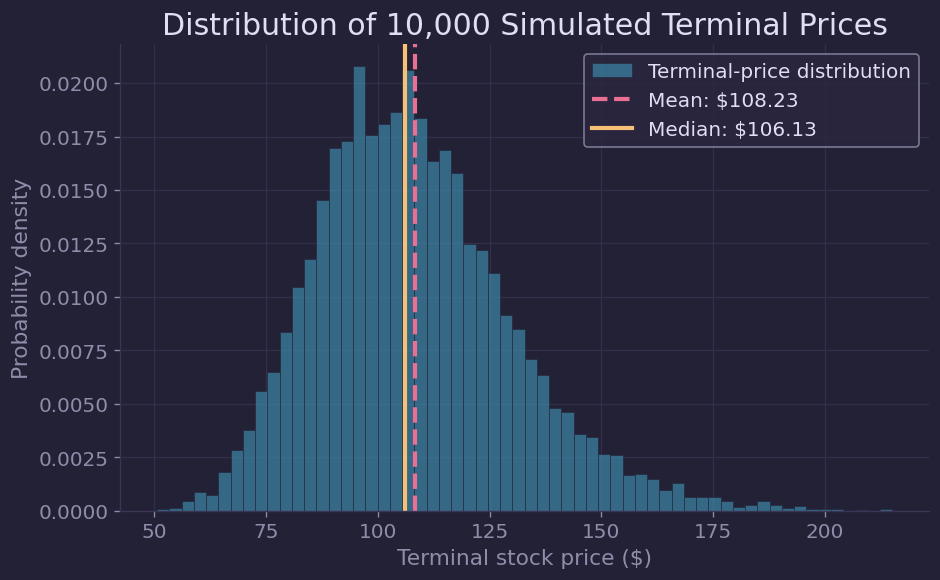

In [204]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(terminal_prices,bins=60,density=True,color=rose_pine["pine"],alpha=0.65,edgecolor=rose_pine["base"],linewidth=0.5,
        label="Terminal-price distribution")

ax.axvline(simulated_mean,color=rose_pine["love"],linestyle="--", linewidth=2.5,label=f"Mean: ${simulated_mean:.2f}")

ax.axvline(simulated_median,color=rose_pine["gold"],linestyle="-",linewidth=2.5,label=f"Median: ${simulated_median:.2f}")

ax.set_title(f"Distribution of {n_paths:,} Simulated Terminal Prices")
ax.set_xlabel("Terminal stock price ($)")
ax.set_ylabel("Probability density")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Volatility Sensitivity Experiment


In [206]:
#define annual volatility of interest
sigma_values = [0.1, 0.2, 0.3]

In [208]:

sensitivity_results = {}

rng_sensitivity = np.random.default_rng(10)
z_sensitivity = rng_sensitivity.standard_normal(
    (n_paths, n_steps))

for sigma_test in sigma_values:

    log_increment_test = ((mu - 0.5 * sigma_test**2) * dt
        + sigma_test * np.sqrt(dt) * z_sensitivity)

    log_growth_test = np.cumsum(log_increment_test,axis=1)

    future_prices_test = S0 * np.exp(log_growth_test)

    initial_prices_test = np.full((n_paths, 1),S0)

    price_paths_test = np.column_stack([initial_prices_test,future_prices_test])

    percentiles_test = np.percentile(price_paths_test,[5, 25, 50, 75, 95],axis=0)

    terminal_prices_test = price_paths_test[:, -1]

    sensitivity_results[sigma_test] = {
        "paths": price_paths_test,
        "percentiles": percentiles_test,
        "terminal_mean": np.mean(terminal_prices_test),
        "terminal_median": np.median(terminal_prices_test),
        "terminal_std": np.std(terminal_prices_test)
    }

In [210]:
analytical_mean = S0 * np.exp(mu * T)

for sigma_test in sigma_values:

    result = sensitivity_results[sigma_test]

    analytical_median = S0 * np.exp((mu - 0.5 * sigma_test**2) * T)

    print(f"Volatility: {sigma_test:.0%}")
    print(f"  Simulated mean:   ${result['terminal_mean']:.2f}")
    print(f"  Analytical mean:  ${analytical_mean:.2f}")
    print(f"  Simulated median: ${result['terminal_median']:.2f}")
    print(f"  Analytical median:${analytical_median:.2f}")
    print(f"  Terminal std:     ${result['terminal_std']:.2f}")
    print()

Volatility: 10%
  Simulated mean:   $108.23
  Analytical mean:  $108.33
  Simulated median: $107.79
  Analytical median:$107.79
  Terminal std:     $10.83

Volatility: 20%
  Simulated mean:   $108.13
  Analytical mean:  $108.33
  Simulated median: $106.18
  Analytical median:$106.18
  Terminal std:     $21.78

Volatility: 30%
  Simulated mean:   $108.02
  Analytical mean:  $108.33
  Simulated median: $103.56
  Analytical median:$103.56
  Terminal std:     $33.02



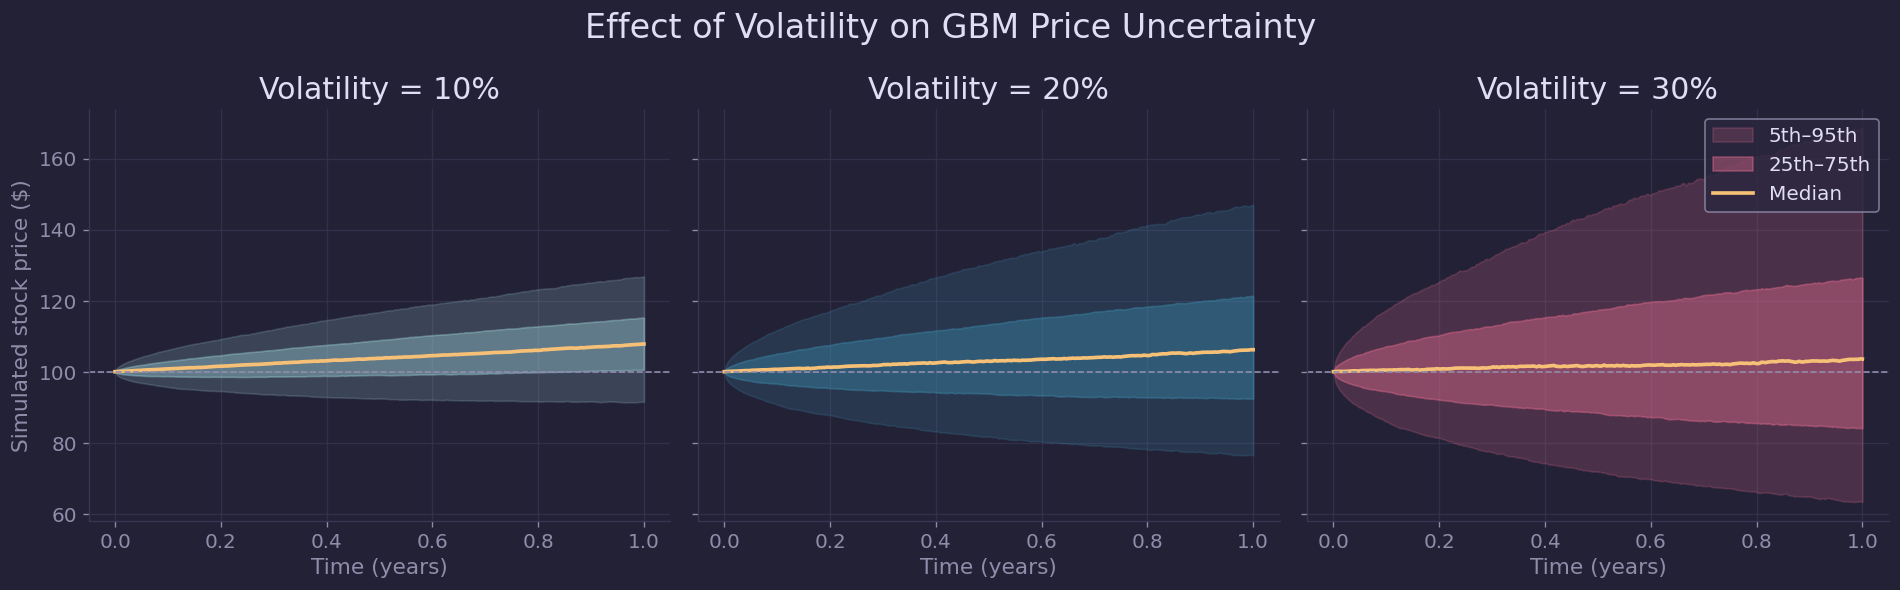

In [212]:
fig, axes = plt.subplots(1,3,figsize=(16, 5),sharex=True,sharey=True)

band_colors = [rose_pine["foam"],rose_pine["pine"],rose_pine["love"]]

for ax, sigma_test, color in zip(axes,sigma_values,band_colors):
    p05_test, p25_test, p50_test, p75_test, p95_test = (sensitivity_results[sigma_test]["percentiles"])

    ax.fill_between(time,p05_test,p95_test,color=color,alpha=0.20,label="5th–95th")

    ax.fill_between(time,p25_test,p75_test,color=color,alpha=0.40,label="25th–75th")

    ax.plot(time,p50_test,color=rose_pine["gold"],linewidth=2.2,label="Median")

    ax.axhline(S0,color=rose_pine["subtle"],linestyle="--",linewidth=1)

    ax.set_title(f"Volatility = {sigma_test:.0%}")
    ax.set_xlabel("Time (years)")

axes[0].set_ylabel("Simulated stock price ($)")
axes[-1].legend()

fig.suptitle("Effect of Volatility on GBM Price Uncertainty",fontsize=20)

plt.tight_layout()
plt.show()

## 10. Conclusions and Limitations

The Monte Carlo simulation agreed closely with analytical GBM predictions. For the baseline 20% volatility scenario, the simulated expected terminal price was within 0.1% of the analytical value, while the simulated and theoretical medians both equaled approximately USD 106.18.

The volatility sensitivity experiment demonstrated that increasing annual volatility from 10% to 30% left the expected terminal price approximately unchanged but increased terminal-price standard deviation from USD 10.83 to USD 33.02. Over the same range, the median fell from USD 107.79 to USD 103.56. Higher volatility therefore widened the distribution, increased right skew, and created a larger difference between the typical outcome and the arithmetic mean.

These results are conditional on GBM assumptions, including constant drift and volatility, independent normally distributed log returns, and continuous price paths. Real markets may exhibit jumps, volatility clustering, changing regimes, and heavier tails.
